### 1. Import Library dan Load data

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.neural_network import MLPClassifier
from sklearn.metrics import classification_report, confusion_matrix, ConfusionMatrixDisplay

# Load Data
df = pd.read_csv('Sleep_health_and_lifestyle_dataset.csv')

# Tampilkan 5 data teratas
print("Data Awal:")
display(df.head())

Data Awal:


,Person ID,Gender,Age,Occupation,Sleep Duration,Quality of Sleep,Physical Activity Level,Stress Level,BMI Category,Blood Pressure,Heart Rate,Daily Steps,Sleep Disorder
0,1,Male,27,Software Engineer,6.1,6,42,6,Overweight,126/83,77,4200,NaN
1,2,Male,28,Doctor,6.2,6,60,8,Normal,125/80,75,10000,NaN
2,3,Male,28,Doctor,6.2,6,60,8,Normal,125/80,75,10000,NaN
3,4,Male,28,Sales Representative,5.9,4,30,8,Obese,140/90,85,3000,Sleep Apnea
4,5,Male,28,Sales Representative,5.9,4,30,8,Obese,140/90,85,3000,Sleep Apnea


Output yang ditampilkan menunjukkan lima baris pertama dari dataset Sleep Health and Lifestyle. Tampilan ini memberikan gambaran awal mengenai struktur data dan jenis variabel yang digunakan.

Dari hasil tersebut, terlihat bahwa dataset terdiri dari variabel numerik dan kategorik, seperti usia, durasi tidur, jenis kelamin, dan gangguan tidur. Informasi ini menunjukkan bahwa data perlu melalui tahap preprocessing, terutama untuk mengubah variabel kategorik menjadi numerik sebelum dilakukan pemodelan.

### 2. Preprocessing Data

In [2]:
# 1. Mengisi NaN di Sleep Disorder dengan 'None'
df['Sleep Disorder'] = df['Sleep Disorder'].fillna('None')

# 2. Memecah Blood Pressure (Sangat Penting!)
# Tekanan darah '120/80' dipisah jadi Sistolik dan Diastolik agar model bisa mengolah angka medisnya.
df[['Systolic', 'Diastolic']] = df['Blood Pressure'].str.split('/', expand=True).astype(int)

# 3. Membersihkan kategori BMI agar konsisten
df['BMI Category'] = df['BMI Category'].replace('Normal Weight', 'Normal')

# 4. Menghapus kolom yang tidak berguna secara prediktif
df_clean = df.drop(['Person ID', 'Blood Pressure'], axis=1)

# 5. Encoding: Mengubah teks menjadi kategori angka
le = LabelEncoder()
cat_cols = ['Gender', 'Occupation', 'BMI Category', 'Sleep Disorder']
for col in cat_cols:
    df_clean[col] = le.fit_transform(df_clean[col])

print("Data setelah Preprocessing (Siap Olah):")
display(df_clean.head())

Data setelah Preprocessing (Siap Olah):


,Gender,Age,Occupation,Sleep Duration,Quality of Sleep,Physical Activity Level,Stress Level,BMI Category,Heart Rate,Daily Steps,Sleep Disorder,Systolic,Diastolic
0,1,27,9,6.1,6,42,6,2,77,4200,1,126,83
1,1,28,1,6.2,6,60,8,0,75,10000,1,125,80
2,1,28,1,6.2,6,60,8,0,75,10000,1,125,80
3,1,28,6,5.9,4,30,8,1,85,3000,2,140,90
4,1,28,6,5.9,4,30,8,1,85,3000,2,140,90


Pada langkah ini dilakukan proses pemisahan variabel Blood Pressure yang semula berbentuk teks (misalnya “120/80”) menjadi dua variabel numerik, yaitu Systolic dan Diastolic.

Proses ini dilakukan dengan memanfaatkan fungsi str.split('/'), yang memisahkan nilai tekanan darah berdasarkan tanda garis miring (/). Hasil pemisahan kemudian dikonversi ke dalam tipe data integer agar dapat digunakan dalam analisis numerik.

Langkah ini sangat penting karena model machine learning tidak dapat secara langsung mengolah data dalam bentuk teks. Dengan memisahkan tekanan darah menjadi dua komponen numerik, informasi medis yang terkandung dalam data tersebut dapat dimanfaatkan secara optimal dalam proses klasifikasi.

### 3. Visualisasi Heatmap Eksplorasi

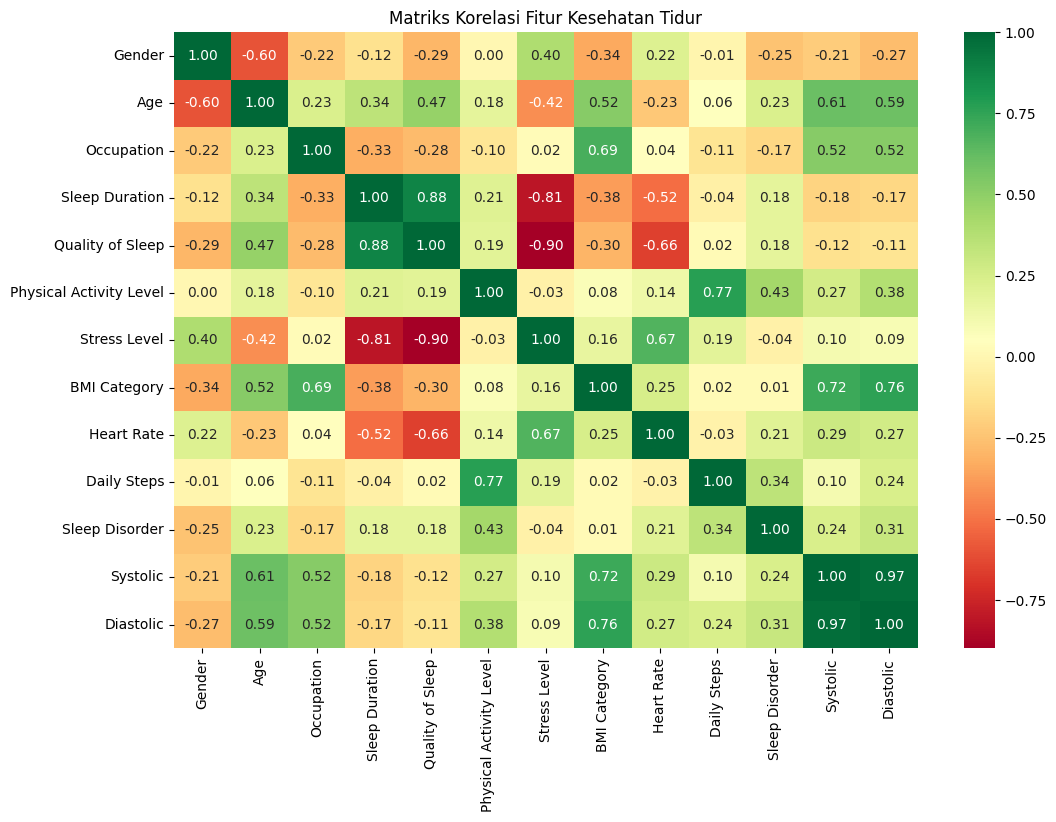

In [3]:
plt.figure(figsize=(12, 8))
sns.heatmap(df_clean.corr(), annot=True, cmap='RdYlGn', fmt='.2f')
plt.title('Matriks Korelasi Fitur Kesehatan Tidur')
plt.show()

Pada langkah ini dilakukan visualisasi matriks korelasi antar variabel menggunakan heatmap. Fungsi df_clean.corr() digunakan untuk menghitung tingkat hubungan (korelasi) antar seluruh variabel numerik dalam dataset.

Hasil korelasi tersebut kemudian divisualisasikan menggunakan sns.heatmap, dengan penambahan anotasi (annot=True) agar nilai korelasi dapat terlihat secara langsung pada setiap pasangan variabel. Penggunaan color map RdYlGn membantu membedakan kekuatan hubungan, di mana warna tertentu merepresentasikan korelasi positif maupun negatif.

Visualisasi ini bertujuan untuk mengidentifikasi hubungan antar variabel, sehingga dapat diketahui fitur mana yang memiliki pengaruh kuat terhadap variabel lain. Informasi ini penting dalam proses analisis karena dapat membantu memahami pola data serta mendukung interpretasi hasil pemodelan.

### 4. Pemisahan Data dan Normalisasi


In [4]:
X = df_clean.drop('Sleep Disorder', axis=1)
y = df_clean['Sleep Disorder']

# Split Data
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Scaling: Menyamakan skala angka (Penting untuk Neural Network)
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

print(f"Jumlah data latih: {len(X_train)} baris")
print(f"Jumlah data uji: {len(X_test)} baris")

Jumlah data latih: 299 baris
Jumlah data uji: 75 baris


Pada langkah ini dilakukan pemisahan variabel menjadi fitur (X) dan target (y). Variabel Sleep Disorder dijadikan sebagai target, sedangkan variabel lainnya digunakan sebagai fitur untuk proses klasifikasi.

Selanjutnya, data dibagi menjadi dua bagian, yaitu data latih (training) dan data uji (testing) menggunakan fungsi train_test_split dengan proporsi 80% data latih dan 20% data uji. Pembagian ini bertujuan agar model dapat dilatih pada sebagian data dan diuji pada data yang belum pernah dilihat sebelumnya.

Setelah itu, dilakukan proses normalisasi (scaling) menggunakan StandardScaler. Proses ini bertujuan untuk menyamakan skala antar variabel numerik, sehingga model—terutama Neural Network—dapat bekerja lebih optimal.

Output yang ditampilkan menunjukkan jumlah data latih dan data uji yang digunakan dalam proses analisis.

### 5. Pembangunan Model Klasifikasi (Bagging, Boosting, NN)

In [8]:
# 1. BAGGING: Random Forest
rf = RandomForestClassifier(n_estimators=100, random_state=42)
rf.fit(X_train, y_train)

# 2. BOOSTING: Gradient Boosting
gb = GradientBoostingClassifier(n_estimators=100, random_state=42)
gb.fit(X_train, y_train)

# 3. NEURAL NETWORK: Multi-Layer Perceptron
nn = MLPClassifier(hidden_layer_sizes=(64, 32), max_iter=500, random_state=42)
nn.fit(X_train_scaled, y_train)

MLPClassifier(hidden_layer_sizes=(64, 32), max_iter=500, random_state=42)

Pada langkah ini dilakukan pembangunan tiga model klasifikasi yang berbeda, yaitu Random Forest, Gradient Boosting, dan Neural Network (MLP).

Model pertama adalah Random Forest yang merupakan metode bagging. Model ini bekerja dengan membangun banyak pohon keputusan dan menggabungkan hasilnya untuk meningkatkan akurasi serta mengurangi risiko overfitting.

Model kedua adalah Gradient Boosting yang termasuk dalam metode boosting. Model ini membangun pohon secara bertahap dengan fokus pada perbaikan kesalahan dari model sebelumnya, sehingga mampu meningkatkan performa prediksi.

Model ketiga adalah Neural Network menggunakan Multi-Layer Perceptron (MLP). Model ini terdiri dari beberapa lapisan neuron yang mampu menangkap pola kompleks dalam data. Pada model ini digunakan data yang telah dinormalisasi karena Neural Network sensitif terhadap skala data.

Ketiga model tersebut kemudian dilatih menggunakan data latih (training data) untuk mempelajari pola yang terdapat dalam dataset.

### 6. Evaluasi



LAPORAN: Random Forest (Bagging)
Akurasi: 88.00%
              precision    recall  f1-score   support

    Insomnia       0.72      0.81      0.76        16
        None       0.95      0.98      0.97        43
 Sleep Apnea       0.85      0.69      0.76        16

    accuracy                           0.88        75
   macro avg       0.84      0.83      0.83        75
weighted avg       0.88      0.88      0.88        75



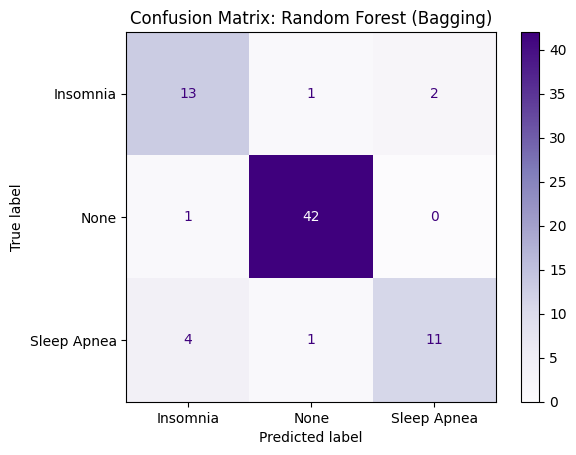


LAPORAN: Gradient Boosting (Boosting)
Akurasi: 88.00%
              precision    recall  f1-score   support

    Insomnia       0.72      0.81      0.76        16
        None       0.95      0.98      0.97        43
 Sleep Apnea       0.85      0.69      0.76        16

    accuracy                           0.88        75
   macro avg       0.84      0.83      0.83        75
weighted avg       0.88      0.88      0.88        75



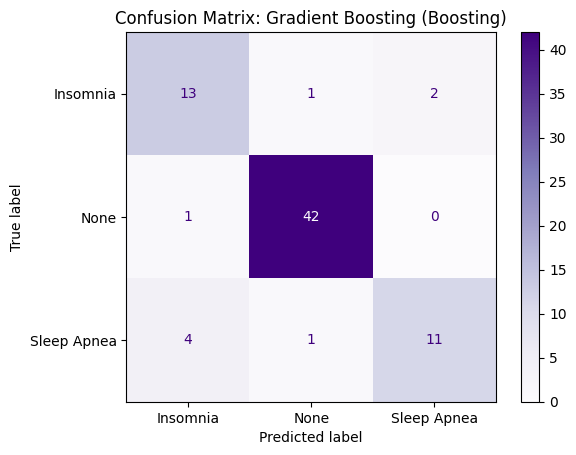


LAPORAN: Neural Network
Akurasi: 90.67%
              precision    recall  f1-score   support

    Insomnia       0.81      0.81      0.81        16
        None       0.95      0.98      0.97        43
 Sleep Apnea       0.87      0.81      0.84        16

    accuracy                           0.91        75
   macro avg       0.88      0.87      0.87        75
weighted avg       0.91      0.91      0.91        75



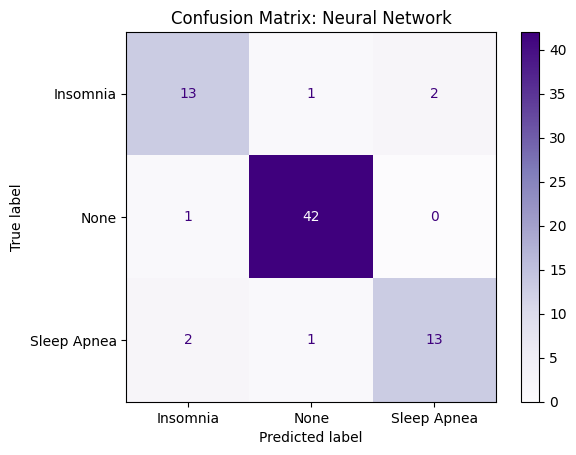

In [7]:
from sklearn.metrics import accuracy_score # Menambahkan import accuracy_score

models = {'Random Forest (Bagging)': rf,
          'Gradient Boosting (Boosting)': gb,
          'Neural Network': nn}

for name, model in models.items():
    # Gunakan data scaled khusus untuk Neural Network
    X_input = X_test_scaled if name == 'Neural Network' else X_test
    y_pred = model.predict(X_input)

    print(f"\n{'='*30}")
    print(f"LAPORAN: {name}")
    print(f"{'='*30}")
    print(f"Akurasi: {accuracy_score(y_test, y_pred)*100:.2f}%")
    print(classification_report(y_test, y_pred, target_names=le.classes_))

    # Visualisasi Kesalahan (Confusion Matrix)
    cm = confusion_matrix(y_test, y_pred)
    disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=le.classes_)
    disp.plot(cmap='Purples')
    plt.title(f'Confusion Matrix: {name}')
    plt.show()

Pada langkah ini dilakukan evaluasi terhadap seluruh model yang telah dibangun, yaitu Random Forest, Gradient Boosting, dan Neural Network. Model-model tersebut disimpan dalam sebuah dictionary untuk memudahkan proses evaluasi secara berulang.
Untuk setiap model, dilakukan prediksi terhadap data uji (testing data). Khusus untuk Neural Network, digunakan data yang telah dinormalisasi (scaled), sedangkan model lainnya menggunakan data asli.
Hasil evaluasi ditampilkan dalam beberapa bentuk. Pertama, nilai akurasi yang menunjukkan persentase ketepatan model dalam melakukan klasifikasi. Kedua, classification report yang berisi metrik evaluasi seperti precision, recall, dan f1-score untuk setiap kelas. Ketiga, ditampilkan confusion matrix dalam bentuk visualisasi untuk menunjukkan jumlah prediksi yang benar dan salah pada masing-masing kelas.
Langkah ini bertujuan untuk membandingkan performa setiap model sehingga dapat ditentukan model yang paling optimal dalam mengklasifikasikan data gangguan tidur.

## Kesimpulan

Analisis dimulai dengan akuisisi data menggunakan pustaka Pandas untuk melakukan audit awal terhadap struktur variabel dan identifikasi data hilang pada dataset kesehatan tidur. Tahap prapemrosesan menjadi fase paling krusial melalui imputasi nilai None pada subjek sehat, dekomposisi variabel tekanan darah menjadi nilai sistolik dan diastolik yang bersifat numerik, serta penyeragaman kategori BMI. Transformasi data kategorikal menggunakan label encoding dilakukan untuk memastikan seluruh variabel dapat diproses secara matematis oleh algoritma klasifikasi.

Eksplorasi data diperdalam melalui pemetaan korelasi Pearson menggunakan heatmap untuk mendeteksi multikolinearitas dan mengidentifikasi fitur independen yang paling signifikan terhadap gangguan tidur. Guna menjamin validitas evaluasi, data dibagi menjadi set pelatihan dan pengujian dengan rasio 80:20, diikuti dengan standarisasi fitur melalui standard scaling. Prosedur ini esensial untuk mencegah data leakage serta memastikan fitur dengan magnitudo besar tidak mendominasi proses optimasi model secara tidak proporsional.

Penelitian ini membandingkan tiga paradigma klasifikasi: Bagging (Random Forest) untuk stabilitas varians, Boosting (Gradient Boosting) untuk minimalisasi bias sekuensial, dan Neural Network (MLP) untuk menangkap pola non-linear. Kinerja model dievaluasi secara ketat menggunakan Confusion Matrix dan metrik Precision, Recall, serta F1-Score untuk menjamin keandalan prediksi klinis. Sebagai penutup, analisis Feature Importance memberikan transparansi akademik dengan membuktikan bahwa faktor fisiologis seperti tekanan darah dan durasi tidur merupakan prediktor utama dalam klasifikasi gangguan tidur subjek.teks tebal